# Importing Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_Fact=pd.read_excel('../Processed versions of data/Cleaned_Customer_Churn_Dataset.xlsx',sheet_name='Fact_Customer_Churn')
df_customer=pd.read_excel('../Processed versions of data/Cleaned_Customer_Churn_Dataset.xlsx',sheet_name='Dim_Customer')
df_Subscription=pd.read_excel('../Processed versions of data/Cleaned_Customer_Churn_Dataset.xlsx',sheet_name='Dim_Subscription')
df_Contract=pd.read_excel('../Processed versions of data/Cleaned_Customer_Churn_Dataset.xlsx',sheet_name='Dim_Contract')

In [3]:
df = (
    df_Fact
    .merge(df_customer, on="CustomerID", how="left")
    .merge(df_Subscription, on="Subscription Type ID", how="left")
    .merge(df_Contract, on="Contract Length ID", how="left")
)

In [4]:
df.sample(5)

,CustomerID,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Subscription Type ID,Contract Length ID,Age,Gender,Subscription Type,Contract Length
151531,156342,29,4,7,21,963.00,8,1,1,1,43,Female,Standard,Monthly
202395,207337,16,7,0,16,991.12,5,1,3,1,53,Male,Premium,Monthly
187615,192426,16,12,6,9,609.00,26,1,3,2,30,Male,Premium,Quarterly
404528,411644,51,13,3,10,504.35,11,0,2,3,37,Female,Basic,Annual
30510,30519,50,21,8,26,779.00,21,1,2,3,19,Female,Basic,Annual


In [5]:
df_dict=pd.read_excel('../Original Data/Dictionary.xlsx')

In [6]:
df_dict.set_index('Column',inplace=True)

# Additional useful columns for analysis

Dividing Age into groups

In [7]:
bins = [18, 30, 42, 54, 66]
labels = ["18-30", "30-42", "42-54", "54-66"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)


Dividing Tenure into groups

In [8]:
bins = [0, 12, 24, 36, 48, 60]

labels = [
    "1-Year",
    "2-Years",
    "3-Years",
    "4-Years",
    "5-Years"
]

df["Tenure_Group"] = pd.cut(df["Tenure"], bins=bins, labels=labels, right=False)

Dividing last interaction into groups

In [9]:
bins = [0, 7, 14, 30]
labels = ['Very Active [Week]', 'Active [2Weeks]', 'At Risk [More]']

df['Interaction_Level'] = pd.cut(df['Last Interaction'], bins=bins, labels=labels, right=True, include_lowest=True)

Naming Churn Values

In [10]:
df['Churn Category'] = df['Churn'].map({0: 'Retained', 1: 'Churned'})

Dividing Usage Frequency into groups

In [11]:
bins = [0, 10, 20, float("inf")]
labels = ['1–10 per month', '10–20 per month', '20+ per month']

df["Usage Group"] = pd.cut(df["Usage Frequency"], bins=bins, labels=labels, include_lowest=True)

Dividing Payment delays into groups

In [12]:
bins = [0, 10, 20, float("inf")]
labels = ['1–10 days', '10–20 days', '20+days']
df["Payment Delay Group"] = pd.cut(df["Payment Delay"], bins=bins, labels=labels, include_lowest=True)

# Exploration

In [13]:
df_dict.loc[:].to_dict()

{'Description ': {'CustomerID': 'A unique identifier for each customer',
  'Age': 'The age of the customer',
  'Gender': 'Gender of the customer',
  'Tenure': "Duration in months for which a customer has been using the company's products or services",
  'Usage Frequency': 'Number of times that the customer has used the company’s services in the last month',
  'Support Calls': 'Number of calls that the customer has made to the customer support in the last month',
  'Payment Delay': 'Number of days that the customer has delayed their payment in the last month',
  'Subscription Type': 'Type of subscription the customer has choosen',
  'Contract Length': 'Duration of the contract that the customer has signed with the company',
  'Total Spend': "Total amount of money the customer has spent on the company's products or services",
  'Last Interaction': '\xa0Number of days since the last interaction that the customer had with the company',
  'Churn': 'Binary label indicating whether a customer

In [14]:
print('Num Of Rows:', df.shape[0])
print('Num Of Columns:', df.shape[1])

Num Of Rows: 440832
Num Of Columns: 20


In [15]:
df.loc[:,['Age','Tenure','Usage Frequency','Support Calls','Payment Delay','Total Spend','Last Interaction']].describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868
std,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000
25%,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000
50%,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000
75%,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000


#### Churn exploration

In [16]:
round(df['Churn Category'].value_counts(normalize=True)*100,1).astype(str)+'%'

Churn Category
Churned     56.7%
Retained    43.3%
Name: proportion, dtype: object

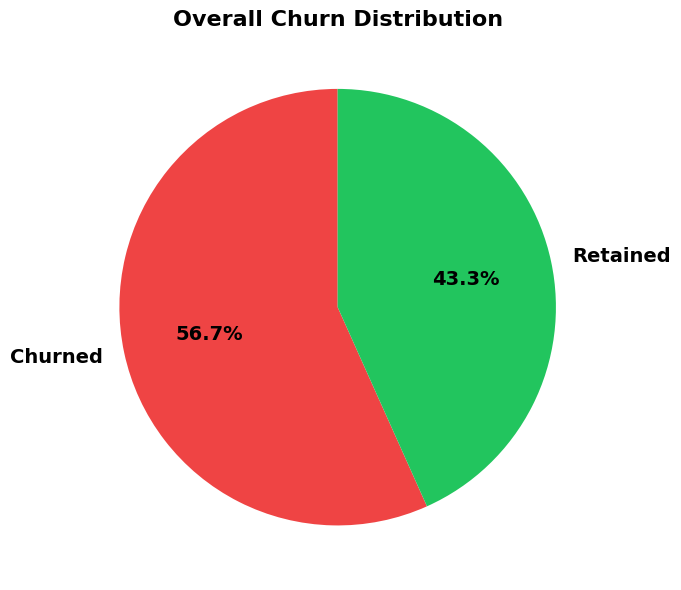

In [17]:
plt.figure(figsize=(10, 6))
churn_counts = df['Churn'].value_counts()
colors = ['#ef4444','#22c55e']
plt.pie(churn_counts, labels=['Churned', 'Retained'], autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 14, 'weight': 'bold'})
plt.title('Overall Churn Distribution', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

#### Subscription Type exploration

In [18]:
(df['Subscription Type'].value_counts(normalize=True)*100).round(1).astype(str)+'%'

Subscription Type
Standard    33.8%
Premium     33.7%
Basic       32.4%
Name: proportion, dtype: object

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\3826621926.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subscription_counts.index, y=subscription_counts.values, palette="viridis")


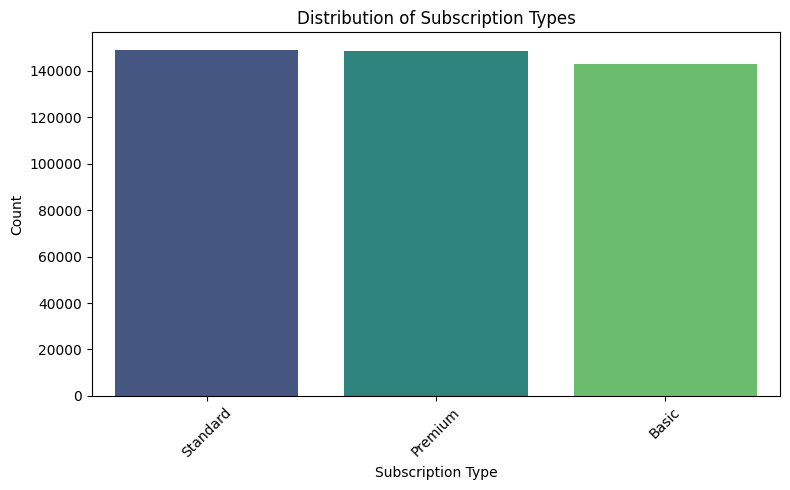

In [19]:
column_name = "Subscription Type"

subscription_counts = df[column_name].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=subscription_counts.index, y=subscription_counts.values, palette="viridis")

plt.xlabel("Subscription Type")
plt.ylabel("Count")
plt.title("Distribution of Subscription Types")
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

#### Gender exploration

In [20]:
(df['Gender'].value_counts(normalize=True)*100).round(1).astype(str)+'%'

Gender
Male      56.8%
Female    43.2%
Name: proportion, dtype: object

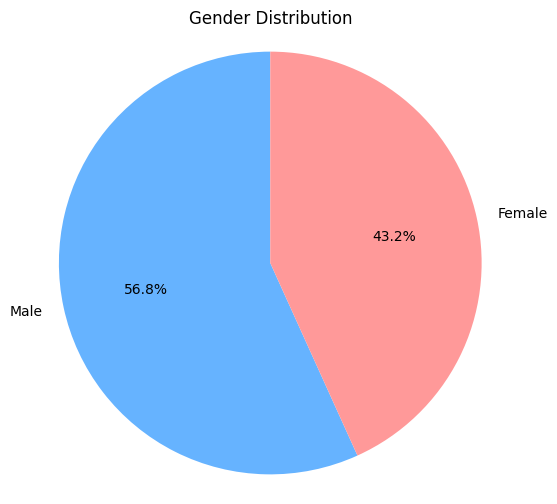

In [21]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66b3ff", "#ff9999", "#99ff99", "#ffcc99"]  
)

plt.title("Gender Distribution")
plt.axis("equal") 
plt.show()

#### Contract Length exploration

In [22]:
(df['Contract Length'].value_counts(normalize=True)*100).round(1).astype(str) + '%'

Contract Length
Annual       40.2%
Quarterly    40.0%
Monthly      19.8%
Name: proportion, dtype: object

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\262956716.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subscription_counts.index, y=subscription_counts.values, palette="viridis")


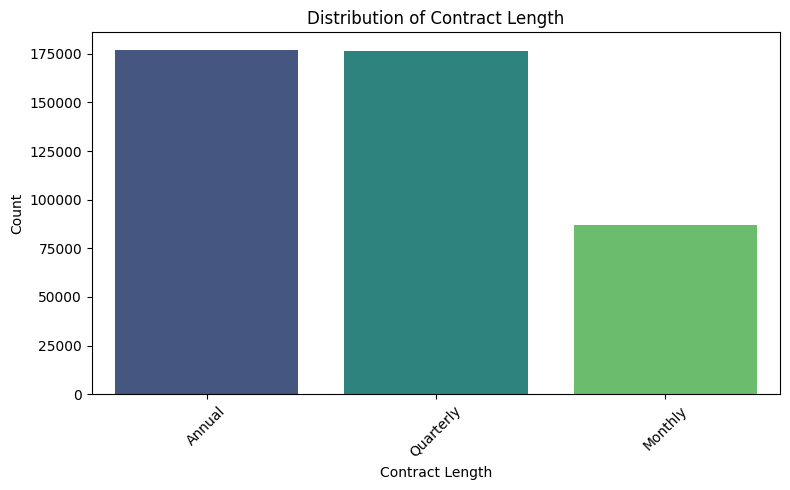

In [23]:
column_name = "Contract Length"

subscription_counts = df[column_name].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=subscription_counts.index, y=subscription_counts.values, palette="viridis")

plt.xlabel("Contract Length")
plt.ylabel("Count")
plt.title("Distribution of Contract Length")
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

#### Age exploration

In [24]:
(df['Age_Group'].value_counts(normalize=True)*100).round(1).astype(str) + '%'

Age_Group
30-42    30.6%
42-54    29.2%
18-30    25.4%
54-66    14.8%
Name: proportion, dtype: object

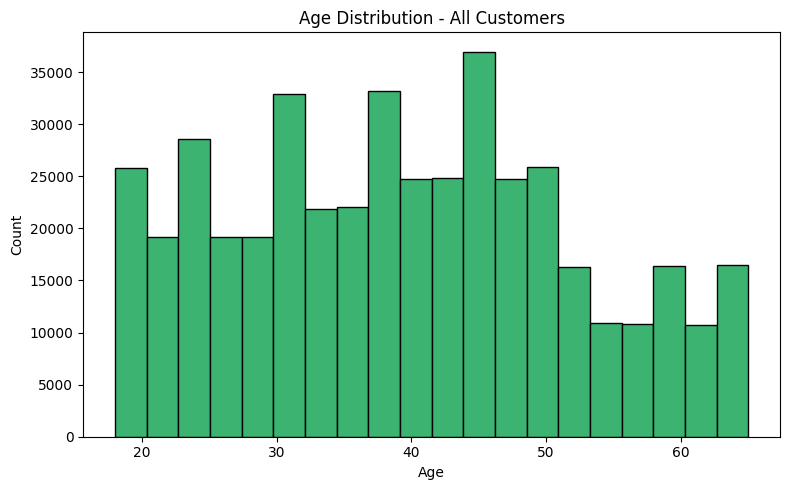

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Age"],
    bins=20,
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Age Distribution - All Customers")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#### Tenure exploration

In [26]:
(df['Tenure_Group'].value_counts(normalize=True)*100).round(1).astype(str) + '%'    

Tenure_Group
5-Years    21.3%
4-Years    21.2%
3-Years    20.9%
2-Years    18.5%
1-Year     18.1%
Name: proportion, dtype: object

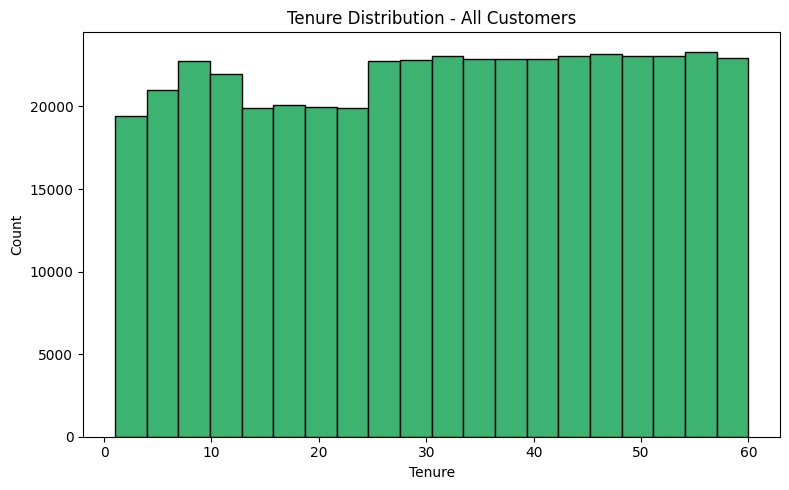

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Tenure"],
    bins=20,
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Tenure Distribution - All Customers")
plt.xlabel("Tenure")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#### Usage Frequency exploration

In [28]:
(df['Usage Group'].value_counts(normalize=True)*100).round(1).astype(str) + '%'
# واضح ان العملاء كان بيستخدموا الخدمه كتير في الشهر الاخير

Usage Group
20+ per month      34.3%
10–20 per month    34.3%
1–10 per month     31.4%
Name: proportion, dtype: object

In [29]:
(df.groupby('Usage Group')['Churn'].value_counts(normalize=True)*100).round(1).astype(str) + '%'
# واضح ان نسبه churn عاليه في كل groups بس عاليه بشكل ملحوظ اكتر في اول جروب اللي فيه الاستخدام كان اقل

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\1690198980.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby('Usage Group')['Churn'].value_counts(normalize=True)*100).round(1).astype(str) + '%'


Usage Group      Churn
1–10 per month   1        60.6%
                 0        39.4%
10–20 per month  1        54.8%
                 0        45.2%
20+ per month    1        55.0%
                 0        45.0%
Name: proportion, dtype: object

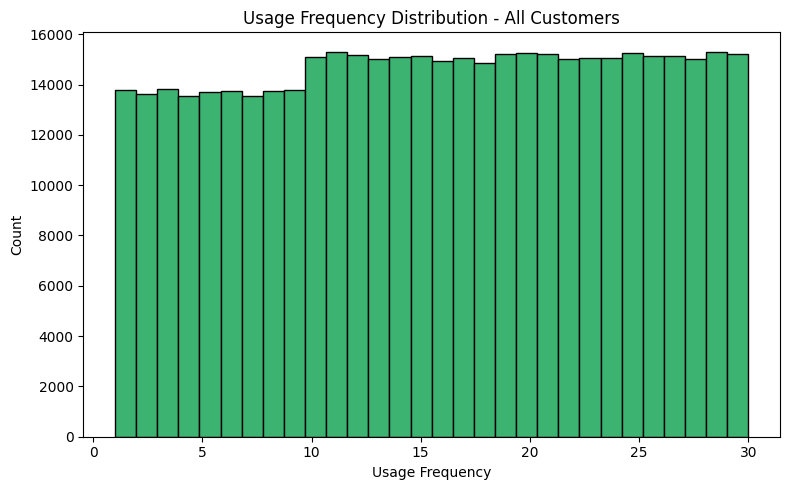

In [30]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Usage Frequency"],
    bins=30,
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Usage Frequency Distribution - All Customers")
plt.xlabel("Usage Frequency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#### Support Calls exploration

In [31]:
(df['Support Calls'].value_counts(normalize=True)*100).round(1).astype(str) + '%'

Support Calls
0     15.9%
1     15.8%
2     15.1%
3     12.0%
4      8.8%
5      5.7%
10     5.4%
7      5.4%
9      5.4%
8      5.3%
6      5.3%
Name: proportion, dtype: object

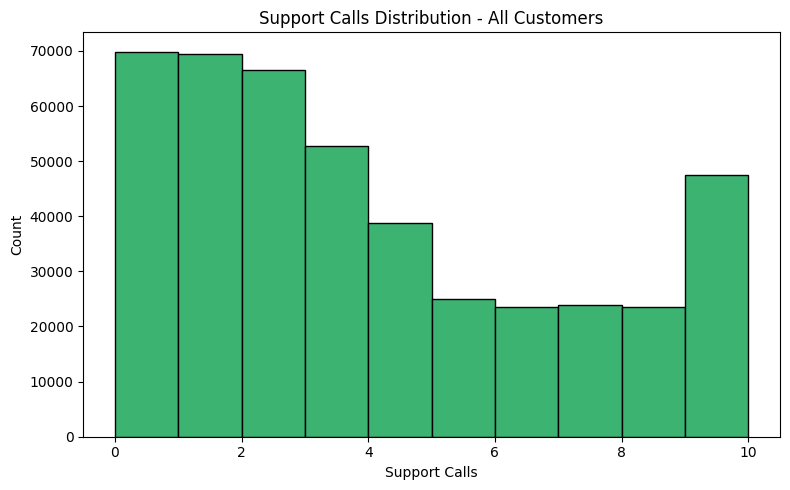

In [32]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Support Calls"],
    bins=10,
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Support Calls Distribution - All Customers")
plt.xlabel("Support Calls")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#### Payment Delay exploration

In [33]:
(df['Payment Delay Group'].value_counts(normalize=True)*100).round(1).astype(str) + '%'

Payment Delay Group
1–10 days     42.2%
10–20 days    38.7%
20+days       19.1%
Name: proportion, dtype: object

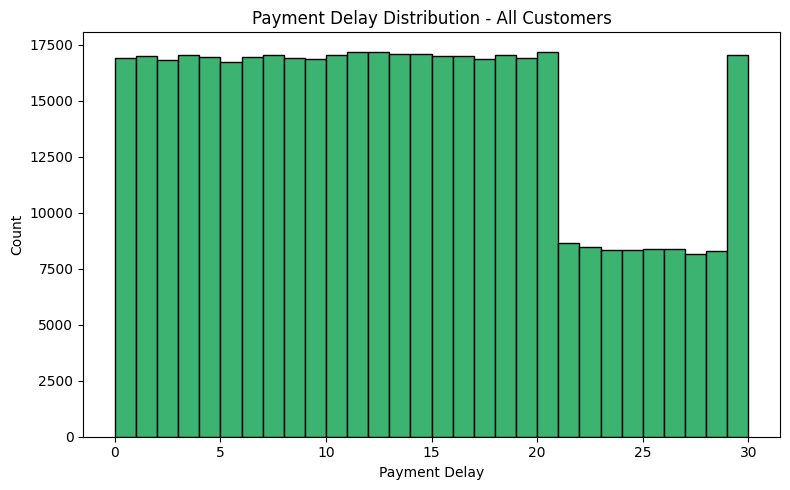

In [34]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Payment Delay"],
    bins=30,
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Payment Delay Distribution - All Customers")
plt.xlabel("Payment Delay")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#### Total Spend exploration

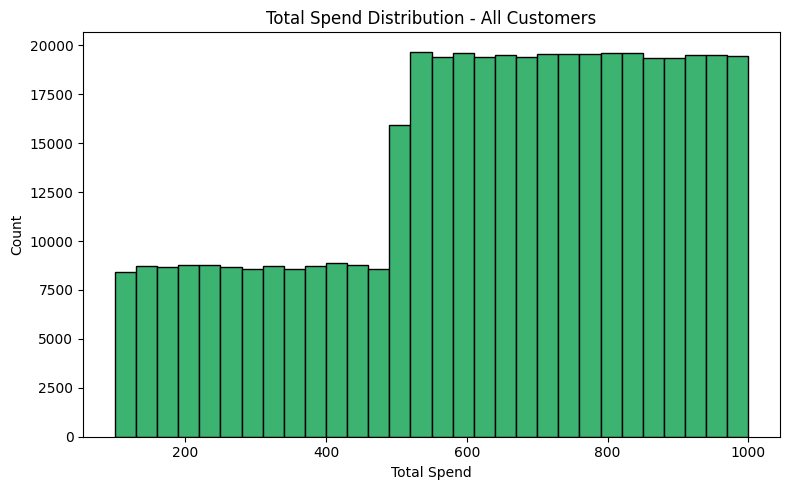

In [35]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Total Spend"],
    bins=30,
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Total Spend Distribution - All Customers")
plt.xlabel("Total Spend")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#### Last Interaction exploration

In [36]:
(df['Interaction_Level'].value_counts(normalize=True)*100).round(1).astype(str) + '%'

Interaction_Level
At Risk [More]        47.0%
Very Active [Week]    26.6%
Active [2Weeks]       26.5%
Name: proportion, dtype: object

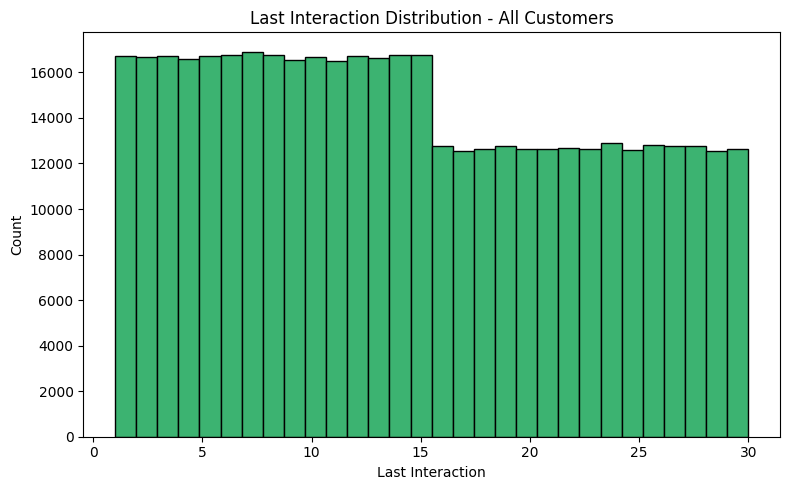

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Last Interaction"],
    bins=30,
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Last Interaction Distribution - All Customers")
plt.xlabel("Last Interaction")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Overview KPIs

Total Customers

In [38]:
total_customers = len(df)
print(f'Total Customers = {total_customers}')

Total Customers = 440832


Customer Churn Rate

In [39]:
Churn_Rate = round((len(df[df['Churn']==1]) / len(df))*100,2)
print(f'Churn Rate = {Churn_Rate}%')

Churn Rate = 56.71%


Revenue Churn Rate

In [40]:
Revenue_Churn_Rate = round(((df[df['Churn']==1])['Total Spend'].sum() / sum(df['Total Spend']))*100,2)
print(f'Revenue_Churn_Rate ={Revenue_Churn_Rate}%')

Revenue_Churn_Rate =48.6%


Retention Rate

In [41]:
Retention_Rate = round((len(df[df['Churn']==0]) / len(df))*100,2)
print(f'Retention Rate ={Retention_Rate}%')

Retention Rate =43.29%


Customer LifeTime - CLV

In [42]:
CLV = round(df[df['Churn']==1]['Tenure'].mean(),2)
print('Average Customer Lifetime=', CLV,'Months')

Average Customer Lifetime= 30.47 Months


# EDA

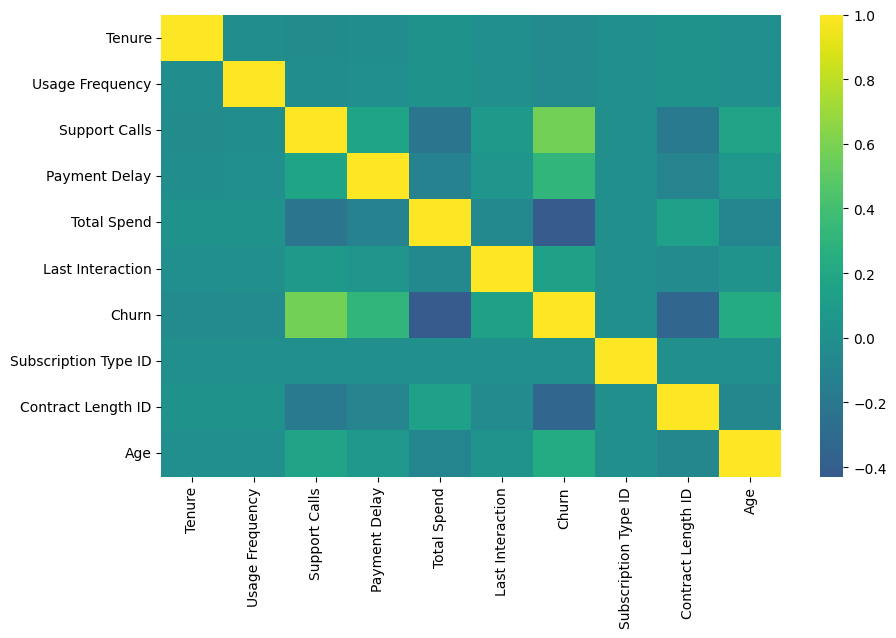

In [43]:
numeric_cols = df.select_dtypes(include='number').columns.drop('CustomerID')     # note : support calls , churn

plt.figure(figsize=(10, 6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=False,
    cmap='viridis',  
    center=0
)
plt.show()

### Subscription Type

percentage of each subscription type

In [44]:
(df['Subscription Type'].value_counts(normalize=True)*100).round(1).astype(str) + '%'

Subscription Type
Standard    33.8%
Premium     33.7%
Basic       32.4%
Name: proportion, dtype: object

In [45]:
round(df.groupby('Churn Category')['Subscription Type'].value_counts(normalize=True)*100,1).astype(str)+'%'

Churn Category  Subscription Type
Churned         Standard             33.4%
                Basic                33.3%
                Premium              33.3%
Retained        Standard             34.3%
                Premium              34.3%
                Basic                31.3%
Name: proportion, dtype: object

<Figure size 1200x600 with 0 Axes>

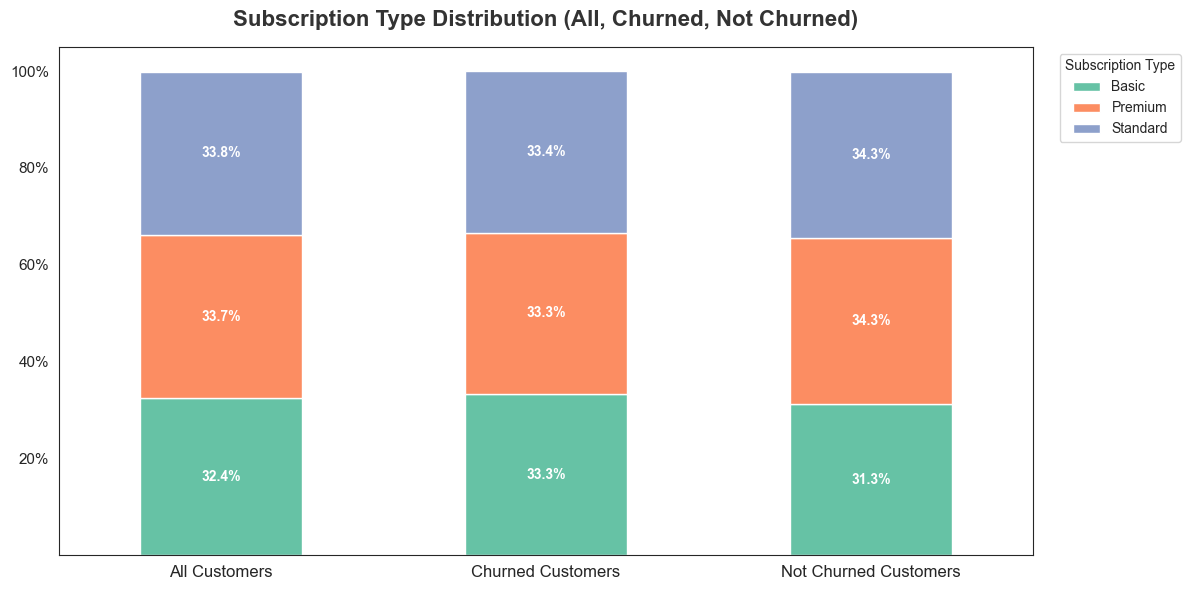

In [46]:
all_sub = (df['Subscription Type'].value_counts(normalize=True) * 100).round(1)
churn_sub = (df.loc[df['Churn'] == 1, 'Subscription Type'].value_counts(normalize=True) * 100).round(1)
not_churn_sub = (df.loc[df['Churn'] == 0, 'Subscription Type'].value_counts(normalize=True) * 100).round(1)


compare_df = pd.DataFrame({
    'All Customers': all_sub,
    'Churned Customers': churn_sub,
    'Not Churned Customers': not_churn_sub
}).fillna(0).T


plt.figure(figsize=(12,6))
sns.set_style("white")

ax = compare_df.plot(
    kind='bar',
    stacked=True,
    color=sns.color_palette("Set2"),
    edgecolor='white',
    figsize=(12,6)
)


plt.title("Subscription Type Distribution (All, Churned, Not Churned)",
          fontsize=16, fontweight='bold', color='#333333', pad=15)

plt.ylabel("")
plt.grid(False)

plt.yticks([20,40,60,80,100], ['20%','40%','60%','80%','100%'], fontsize=11)
plt.xticks(rotation=0, fontsize=12)

plt.legend(title="Subscription Type", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height():.1f}%" if v.get_height() > 0 else "" for v in container],
        label_type='center',
        fontsize=10,
        color='white',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [47]:
(df.groupby('Subscription Type')['Churn'].mean()*100).round(1).astype(str) + '%'

Subscription Type
Basic       58.2%
Premium     55.9%
Standard    56.1%
Name: Churn, dtype: object

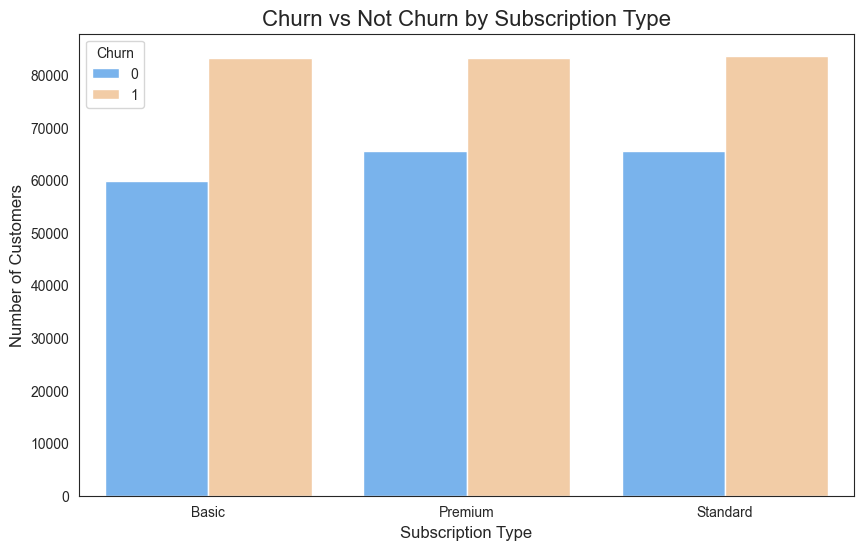

In [48]:
subscription_churn_counts = df.groupby(['Subscription Type', 'Churn'], observed=True).size().reset_index(name='Count')

plt.figure(figsize=(10,6))
sns.barplot(x='Subscription Type', y='Count', hue='Churn', data=subscription_churn_counts, palette=['#66b3ff','#ffcc99'])

plt.title('Churn vs Not Churn by Subscription Type', fontsize=16)
plt.xlabel('Subscription Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

In [49]:
df.groupby('Subscription Type')['Total Spend'].mean()

Subscription Type
Basic       628.673496
Premium     632.926463
Standard    633.132253
Name: Total Spend, dtype: float64

In [140]:
df[df['Churn']==1].groupby('Subscription Type')['Total Spend'].mean()

Subscription Type
Basic       541.742857
Premium     540.639802
Standard    541.472723
Name: Total Spend, dtype: float64

In [50]:
df.groupby('Subscription Type')['Tenure'].mean()             #basic

Subscription Type
Basic       31.935347
Premium     30.883460
Standard    30.976859
Name: Tenure, dtype: float64

In [141]:
df[df['Churn']==1].groupby('Subscription Type')['Tenure'].mean() 

Subscription Type
Basic       30.355005
Premium     30.449870
Standard    30.615217
Name: Tenure, dtype: float64

In [51]:
df.groupby('Subscription Type')['Payment Delay'].mean()

Subscription Type
Basic       13.026310
Premium     12.916766
Standard    12.956420
Name: Payment Delay, dtype: float64

In [143]:
df[df['Churn']==1].groupby('Subscription Type')['Payment Delay'].mean() 

Subscription Type
Basic       15.192501
Premium     15.204249
Standard    15.256243
Name: Payment Delay, dtype: float64

In [52]:
df.groupby('Subscription Type')['Support Calls'].mean()

Subscription Type
Basic       3.652196
Premium     3.577671
Standard    3.585316
Name: Support Calls, dtype: float64

In [144]:
df[df['Churn']==1].groupby('Subscription Type')['Support Calls'].mean()

Subscription Type
Basic       5.136282
Premium     5.142979
Standard    5.155269
Name: Support Calls, dtype: float64

In [53]:
df.groupby('Subscription Type')['Age'].mean()

Subscription Type
Basic       39.458756
Premium     39.323040
Standard    39.341016
Name: Age, dtype: float64

In [145]:
df[df['Churn']==1].groupby('Subscription Type')['Age'].mean()

Subscription Type
Basic       41.767023
Premium     41.708054
Standard    41.766600
Name: Age, dtype: float64

In [146]:
df.groupby('Subscription Type')['Usage Frequency'].mean()

Subscription Type
Basic       15.808678
Premium     15.809293
Standard    15.804564
Name: Usage Frequency, dtype: float64

In [147]:
df[df['Churn']==1].groupby('Subscription Type')['Usage Frequency'].mean()

Subscription Type
Basic       15.488811
Premium     15.449304
Standard    15.446924
Name: Usage Frequency, dtype: float64

### Contract Length

In [54]:
(df['Contract Length'].value_counts(normalize=True)*100).round(1).astype(str) + '%'

Contract Length
Annual       40.2%
Quarterly    40.0%
Monthly      19.8%
Name: proportion, dtype: object

In [55]:
round(df.groupby('Churn Category')['Contract Length'].value_counts(normalize=True)*100,1).astype(str)+'%'

Churn Category  Contract Length
Churned         Monthly            34.8%
                Annual             32.7%
                Quarterly          32.5%
Retained        Annual             50.1%
                Quarterly          49.9%
Name: proportion, dtype: object

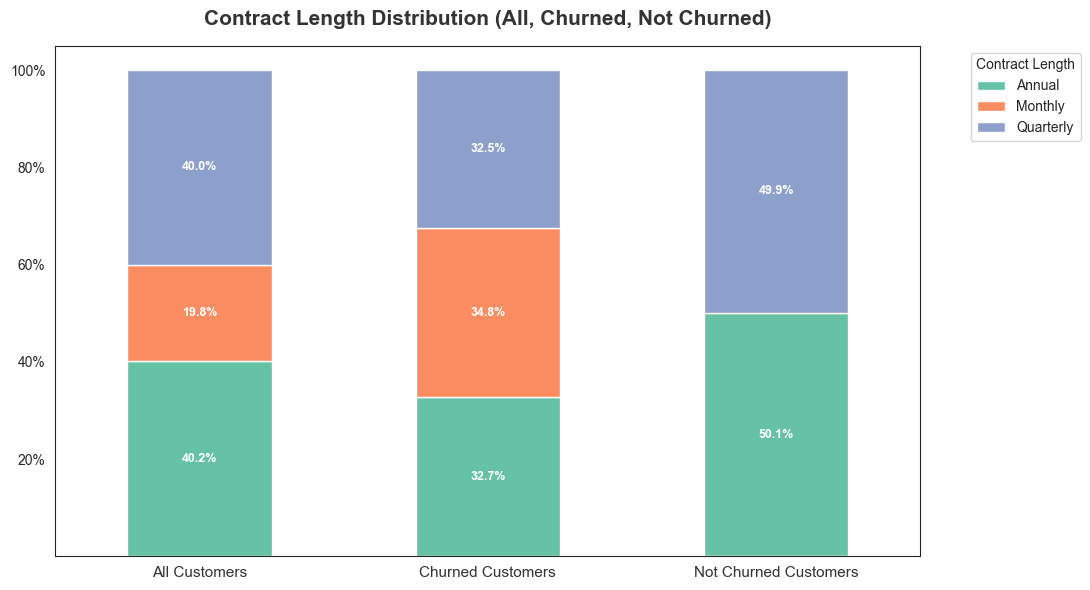

In [ ]:
all_con = (df['Contract Length'].value_counts(normalize=True) * 100).round(1)
churn_con = (df.loc[df['Churn'] == 1, 'Contract Length']
             .value_counts(normalize=True) * 100).round(1)
not_churn_con = (df.loc[df['Churn'] == 0, 'Contract Length']
                 .value_counts(normalize=True) * 100).round(1)

all_lengths = pd.Index(sorted(
    set(all_con.index) | set(churn_con.index) | set(not_churn_con.index)
))

combined_df = pd.DataFrame({
    'All Customers': all_con.reindex(all_lengths, fill_value=0),
    'Churned Customers': churn_con.reindex(all_lengths, fill_value=0),
    'Not Churned Customers': not_churn_con.reindex(all_lengths, fill_value=0)
}).T 

sns.set_style("white")
colors = sns.color_palette("Set2")

fig, ax = plt.subplots(figsize=(11,6))

combined_df.plot(
    kind='bar',
    stacked=True,
    color=colors,
    edgecolor='white',
    figsize=(11,6),
    ax=ax
)

plt.title("Contract Length Distribution (All, Churned, Not Churned)", 
          fontsize=15, fontweight='bold', color='#333333', pad=15)

plt.ylabel("")
plt.xticks(rotation=0, fontsize=11, color='#333333')
plt.yticks([20,40,60,80,100],['20%','40%','60%','80%','100%'])

plt.legend(title="Contract Length", bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v.get_height():.1f}%' if v.get_height() > 0 else '' 
                for v in container],
        label_type='center',
        fontsize=9,
        color='white',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

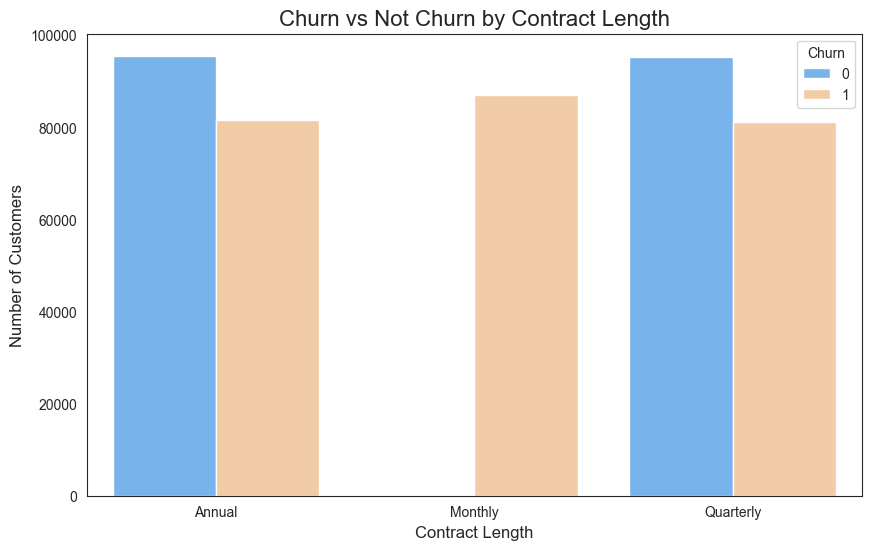

In [57]:
contract_churn_counts = df.groupby(['Contract Length', 'Churn'], observed=True).size().reset_index(name='Count')

plt.figure(figsize=(10,6))
sns.barplot(x='Contract Length', y='Count', hue='Churn', data=contract_churn_counts, palette=['#66b3ff','#ffcc99'])

plt.title('Churn vs Not Churn by Contract Length', fontsize=16)
plt.xlabel('Contract Length', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

In [58]:
(df.groupby('Contract Length')['Churn'].mean()*100).round(1).astype(str) + '%'

Contract Length
Annual        46.1%
Monthly      100.0%
Quarterly     46.0%
Name: Churn, dtype: object

In [59]:
df.groupby('Contract Length')['Age'].mean()

Contract Length
Annual       38.842188
Monthly      41.552282
Quarterly    38.830896
Name: Age, dtype: float64

In [148]:
df[df['Churn']==1].groupby('Contract Length')['Age'].mean()

Contract Length
Annual       41.848566
Monthly      41.552282
Quarterly    41.854497
Name: Age, dtype: float64

In [60]:
df.groupby('Contract Length')['Tenure'].mean()

Contract Length
Annual       31.446213
Monthly      30.538701
Quarterly    31.419838
Name: Tenure, dtype: float64

In [149]:
df[df['Churn']==1].groupby('Contract Length')['Tenure'].mean()

Contract Length
Annual       30.497354
Monthly      30.538701
Quarterly    30.379931
Name: Tenure, dtype: float64

In [150]:
df.groupby('Contract Length')['Support Calls'].mean()

Contract Length
Annual       3.263395
Monthly      4.985649
Quarterly    3.265247
Name: Support Calls, dtype: float64

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\3929848217.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Contract Length', y='Support Calls', data=df, palette='coolwarm')


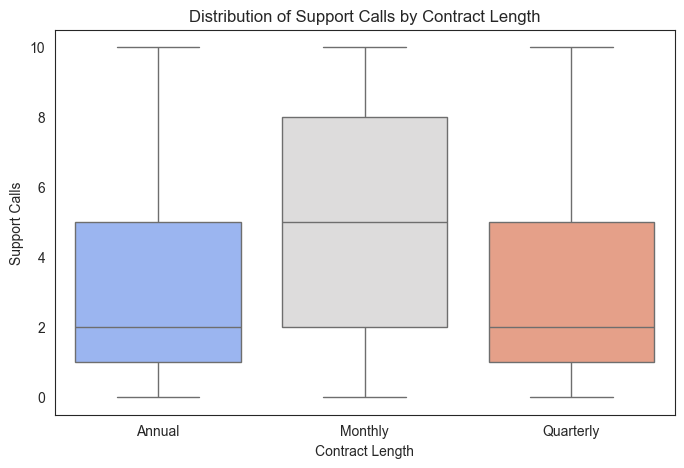

In [63]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Contract Length', y='Support Calls', data=df, palette='coolwarm')
plt.title('Distribution of Support Calls by Contract Length')
plt.xlabel('Contract Length')
plt.ylabel('Support Calls')
plt.show()

In [151]:
df[df['Churn']==1].groupby('Contract Length')['Support Calls'].mean()

Contract Length
Annual       5.228180
Monthly      4.985649
Quarterly    5.231818
Name: Support Calls, dtype: float64

In [152]:
df.groupby('Contract Length')['Usage Frequency'].mean()

Contract Length
Annual       15.880207
Monthly      15.499162
Quarterly    15.886642
Name: Usage Frequency, dtype: float64

In [153]:
df[df['Churn']==1].groupby('Contract Length')['Usage Frequency'].mean()

Contract Length
Annual       15.437817
Monthly      15.499162
Quarterly    15.445409
Name: Usage Frequency, dtype: float64

In [154]:
df.groupby('Contract Length')['Payment Delay'].mean()

Contract Length
Annual       12.465135
Monthly      15.007198
Quarterly    12.460891
Name: Payment Delay, dtype: float64

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\2175556551.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Contract Length', y='Payment Delay', data=df, palette='coolwarm')


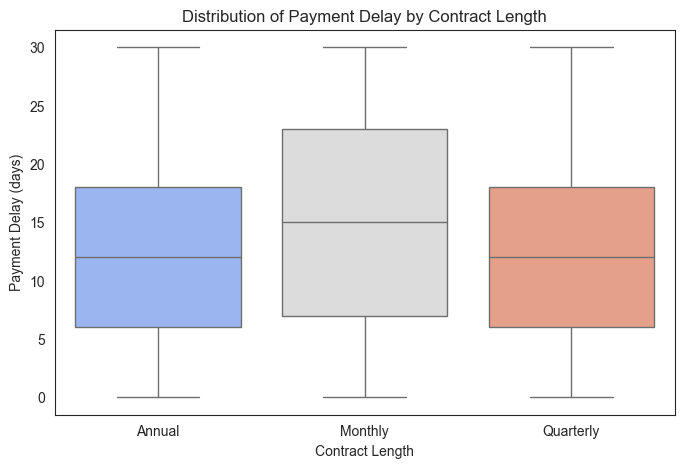

In [65]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Contract Length', y='Payment Delay', data=df, palette='coolwarm')
plt.title('Distribution of Payment Delay by Contract Length')
plt.xlabel('Contract Length')
plt.ylabel('Payment Delay (days)')
plt.show()

In [155]:
df[df['Churn']==1].groupby('Contract Length')['Payment Delay'].mean()

Contract Length
Annual       15.327977
Monthly      15.007198
Quarterly    15.332644
Name: Payment Delay, dtype: float64

In [157]:
df.groupby('Contract Length')['Total Spend'].mean()

Contract Length
Annual       651.696325
Monthly      550.618048
Quarterly    651.426516
Name: Total Spend, dtype: float64

In [156]:
df[df['Churn']==1].groupby('Contract Length')['Total Spend'].mean()

Contract Length
Annual       536.506305
Monthly      550.618048
Quarterly    536.083057
Name: Total Spend, dtype: float64

In [61]:
df.groupby(['Tenure_Group','Contract Length'])['Total Spend'].sum()
# دايما monthly بيكون اقل في total spend رغم انه نفس tenure و ده شيء غريب للغايه 

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\103469671.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Tenure_Group','Contract Length'])['Total Spend'].sum()


Tenure_Group  Contract Length
1-Year        Annual             20377497.96
              Monthly             8706143.37
              Quarterly          20187144.97
2-Years       Annual             20073369.61
              Monthly             9601116.94
              Quarterly          19939633.82
3-Years       Annual             23961638.51
              Monthly             9480405.34
              Quarterly          24074607.34
4-Years       Annual             24408277.79
              Monthly             9762735.96
              Quarterly          24320417.24
5-Years       Annual             24590265.52
              Monthly             9597084.29
              Quarterly          24458260.10
Name: Total Spend, dtype: float64

### Gender

In [66]:
(df['Gender'].value_counts(normalize=True) * 100).round(1).astype(str) + '%'

Gender
Male      56.8%
Female    43.2%
Name: proportion, dtype: object

In [67]:
round(df.groupby(['Churn Category'])['Gender'].value_counts(normalize=True)*100,1).astype(str)+'%'
# percentage in each churn category

Churn Category  Gender
Churned         Female    50.8%
                Male      49.2%
Retained        Male      66.7%
                Female    33.3%
Name: proportion, dtype: object

In [68]:
round((df.groupby(['Churn Category','Gender']).size() / len(df)) * 100,1).astype(str) + '%' #percentage if females who churned is twice equal not churned
# percentage in all data

Churn Category  Gender
Churned         Female    28.8%
                Male      27.9%
Retained        Female    14.4%
                Male      28.9%
dtype: object

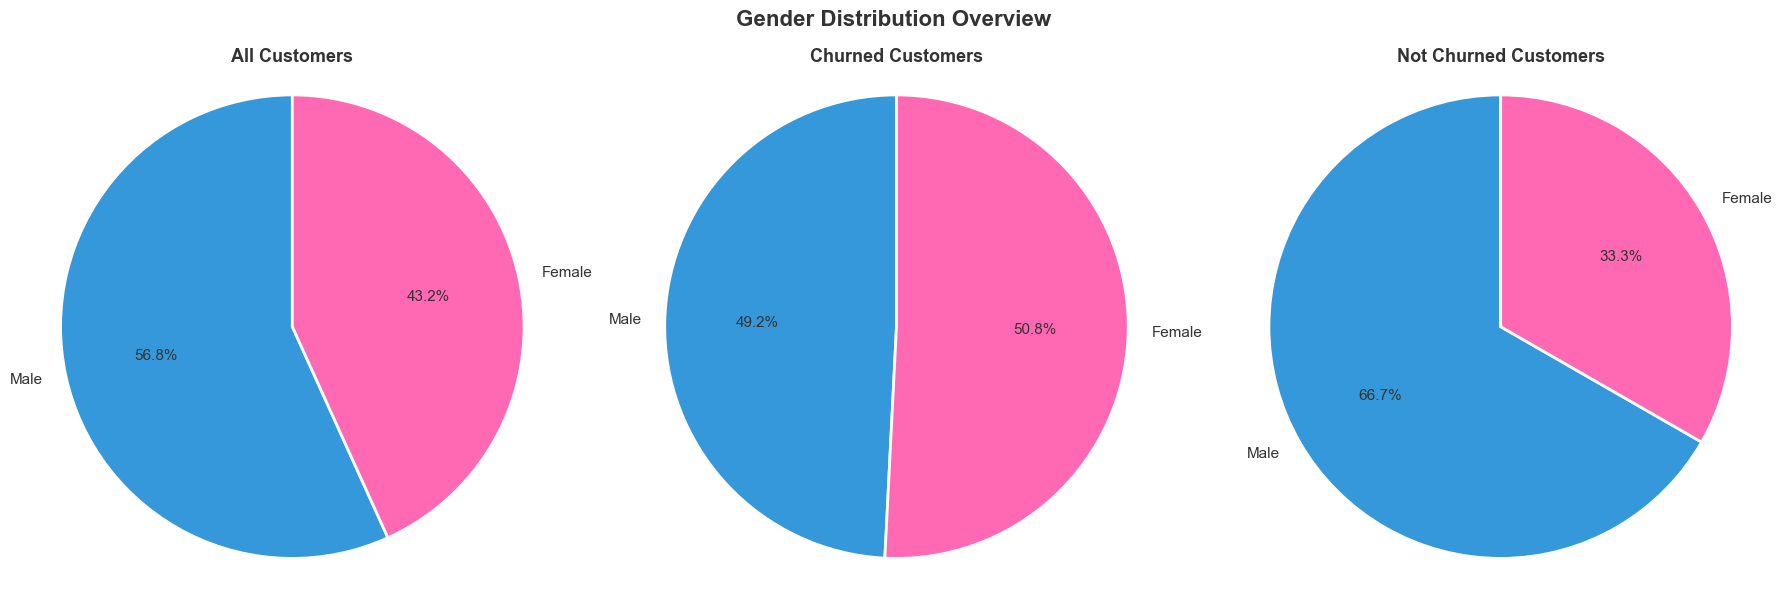

In [ ]:

gender_all = df['Gender'].value_counts()

gender_churn = (
    df.loc[df['Churn'] == 1, 'Gender']
    .value_counts(normalize=True)
    .mul(100).round(1)
    .sort_values()
)

gender_not_churn = (
    df.loc[df['Churn'] == 0, 'Gender']
    .value_counts(normalize=True)
    .mul(100).round(1)
)

colors = ['#3498db', '#ff69b4']


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Gender Distribution Overview", 
             fontsize=16, fontweight='bold', color='#333333', y=0.98)

axes[0].pie(
    gender_all.values,
    labels=gender_all.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11, 'color': '#333'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title("All Customers", fontsize=13, fontweight='bold', color='#333')

axes[1].pie(
    gender_churn.values,
    labels=gender_churn.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11, 'color': '#333'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title("Churned Customers", fontsize=13, fontweight='bold', color='#333')

axes[2].pie(
    gender_not_churn.values,
    labels=gender_not_churn.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11, 'color': '#333'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[2].set_title("Not Churned Customers", fontsize=13, fontweight='bold', color='#333')

for ax in axes:
    ax.axis('equal')

plt.tight_layout()
plt.show()


In [70]:
(df.groupby('Gender')['Churn Category'].value_counts(normalize=True)* 100).round(1).astype(str) + '%'

Gender  Churn Category
Female  Churned           66.7%
        Retained          33.3%
Male    Retained          50.9%
        Churned           49.1%
Name: proportion, dtype: object

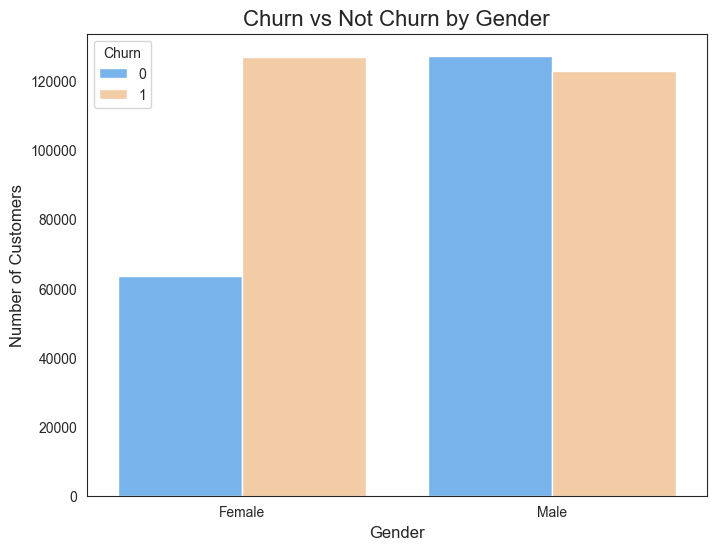

In [71]:
gender_churn_counts = df.groupby(['Gender', 'Churn'], observed=True).size().reset_index(name='Count')


plt.figure(figsize=(8,6))
sns.barplot(x='Gender', y='Count', hue='Churn', data=gender_churn_counts, palette=['#66b3ff','#ffcc99'])

plt.title('Churn vs Not Churn by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

In [72]:
df.groupby('Gender')['Support Calls'].mean()

Gender
Female    3.925338
Male      3.360053
Name: Support Calls, dtype: float64

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\1896384415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Support Calls', data=df,  palette={'Female':'pink', 'Male':'lightblue'})


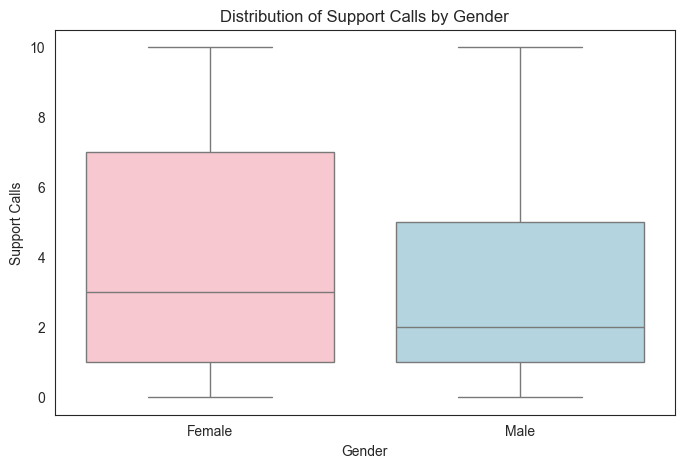

In [73]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Gender', y='Support Calls', data=df,  palette={'Female':'pink', 'Male':'lightblue'})
plt.title('Distribution of Support Calls by Gender')
plt.xlabel('Gender')
plt.ylabel('Support Calls')
plt.show()

In [74]:
df.groupby(['Churn Category','Gender'])['Support Calls'].mean()


Churn Category  Gender
Churned         Female    5.094170
                Male      5.197249
Retained        Female    1.587419
                Male      1.585920
Name: Support Calls, dtype: float64

In [162]:
df.groupby(['Churn Category','Gender'])['Tenure'].mean()

Churn Category  Gender
Churned         Female    30.517842
                Male      30.427872
Retained        Female    32.260178
                Male      32.292520
Name: Tenure, dtype: float64

In [ ]:
df.groupby(['Churn Category','Gender'])['Payment Delay'].mean()

Churn Category  Gender
Churned         Female    15.138094
                Male      15.300030
Retained        Female     9.996001
                Male      10.025230
Name: Payment Delay, dtype: float64

In [164]:
df.groupby(['Churn Category','Gender'])['Total Spend'].mean()

Churn Category  Gender
Churned         Female    545.065739
                Male      537.378726
Retained        Female    749.982420
                Male      749.938488
Name: Total Spend, dtype: float64

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\4129123700.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


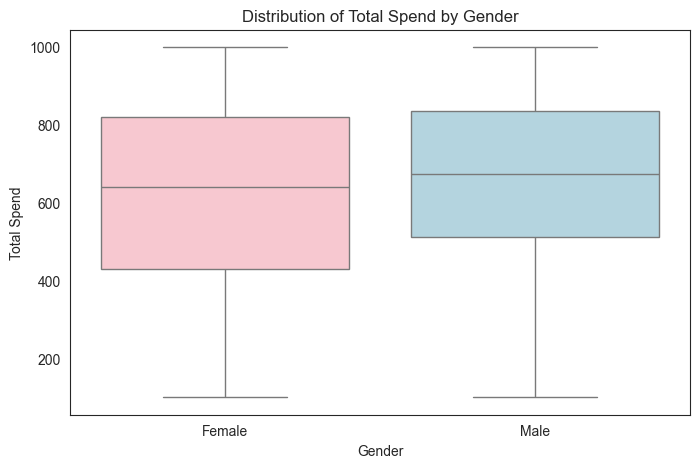

In [78]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Gender',
    y='Total Spend',
    data=df,
    palette={'Female':'pink', 'Male':'lightblue'}
)
plt.title('Distribution of Total Spend by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Spend')
plt.show()

In [165]:
df.groupby(['Churn Category','Gender'])['Last Interaction'].mean()

Churn Category  Gender
Churned         Female    15.726951
                Male      15.478042
Retained        Female     8.005022
                Male      15.505447
Name: Last Interaction, dtype: float64

### Age

In [80]:
df.groupby('Churn Category')['Age'].mean()

Churn Category
Churned     41.747263
Retained    36.262973
Name: Age, dtype: float64

In [81]:
(df.groupby('Age_Group',observed=False)['Churn'].mean()*100).round(1).astype(str) + '%'

Age_Group
18-30     55.5%
30-42     45.3%
42-54     47.7%
54-66    100.0%
Name: Churn, dtype: object

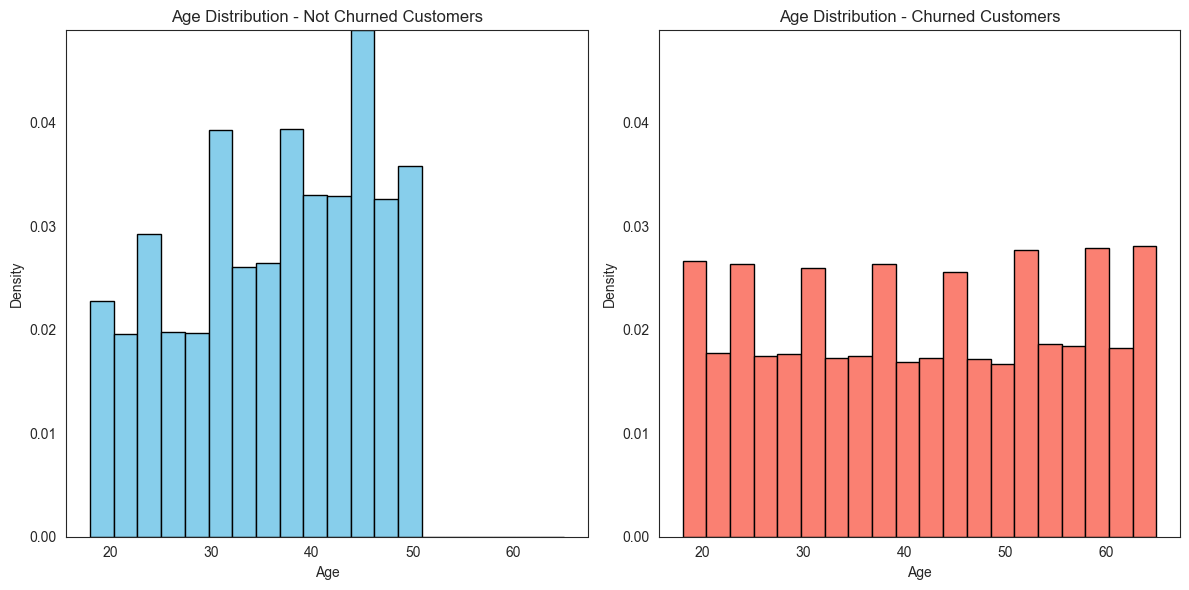

In [ ]:
age_min = df["Age"].min()
age_max = df["Age"].max()

dens_not, _ = np.histogram(
    df[df["Churn"] == 0]["Age"],
    bins=20,
    range=(age_min, age_max),
    density=True
)

dens_churn, _ = np.histogram(
    df[df["Churn"] == 1]["Age"],
    bins=20,
    range=(age_min, age_max),
    density=True
)

y_max = max(dens_not.max(), dens_churn.max())

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(
    df[df["Churn"] == 0]["Age"],
    bins=20,
    range=(age_min, age_max),
    color="skyblue",
    edgecolor="black",
    density=True
)
plt.title("Age Distribution - Not Churned Customers")
plt.xlabel("Age")
plt.ylabel("Density")
plt.ylim(0, y_max)   

plt.subplot(1, 2, 2)
plt.hist(
    df[df["Churn"] == 1]["Age"],
    bins=20,
    range=(age_min, age_max),
    color="salmon",
    edgecolor="black",
    density=True
)
plt.title("Age Distribution - Churned Customers")
plt.xlabel("Age")
plt.ylabel("Density")
plt.ylim(0, y_max)  

plt.tight_layout()
plt.show()

In [171]:
print('Churn rate in over 50 age clients')
(df[df['Age']>50]['Churn'].mean()*100).astype(str)+'%'

Churn rate in over 50 age clients


'100.0%'

In [138]:
len(df[(df['Age']>=40)&(df['Age']<=50)])/len(df)       # تلت العملاء اعمارهم من 40 ل 50

0.31120699041811845

In [139]:
df[(df['Age']>=40)&(df['Age']<=50)]['Churn'].mean()       # نسبه churn بتاعتهم مش كبيره نوعا ما مقارنه بالداتا
# فمحتاجين نحافظ عليهم و نعرف ايه الاسباب اللي بتخليهم يسيبو الخدمه لما يكبروااكتر شويه 

np.float64(0.4009621692543188)

In [ ]:
df.groupby(['Churn Category','Age_Group'])['Total Spend'].mean()
# NAN --> as there is no retained client 

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\454871750.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Churn Category','Age_Group'])['Total Spend'].mean()


Churn Category  Age_Group
Churned         18-30        542.504762
                30-42        534.891723
                42-54        537.214759
                54-66        549.917377
Retained        18-30        749.921201
                30-42        748.994722
                42-54        751.023707
                54-66               NaN
Name: Total Spend, dtype: float64

In [173]:
df.groupby(['Churn Category','Age_Group'])['Usage Frequency'].mean()

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\3171890981.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Churn Category','Age_Group'])['Usage Frequency'].mean()


Churn Category  Age_Group
Churned         18-30        15.484974
                30-42        15.389207
                42-54        15.421392
                54-66        15.544933
Retained        18-30        16.276624
                30-42        16.220553
                42-54        16.292365
                54-66              NaN
Name: Usage Frequency, dtype: float64

In [174]:
df.groupby(['Churn Category','Age_Group'])['Payment Delay'].mean()

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\2355351077.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Churn Category','Age_Group'])['Payment Delay'].mean()


Churn Category  Age_Group
Churned         18-30        15.243291
                30-42        15.315629
                42-54        15.304962
                54-66        15.020127
Retained        18-30        10.003913
                30-42        10.022183
                42-54        10.016769
                54-66              NaN
Name: Payment Delay, dtype: float64

In [175]:
df.groupby(['Churn Category','Age_Group'])['Support Calls'].mean()

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\3712994457.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Churn Category','Age_Group'])['Support Calls'].mean()


Churn Category  Age_Group
Churned         18-30        5.172576
                30-42        5.236812
                42-54        5.166004
                54-66        5.012770
Retained        18-30        0.936187
                30-42        1.596006
                42-54        2.056808
                54-66             NaN
Name: Support Calls, dtype: float64

In [176]:
df.groupby(['Churn Category','Age_Group'])['Tenure'].mean()

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\1075128583.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Churn Category','Age_Group'])['Tenure'].mean()


Churn Category  Age_Group
Churned         18-30        30.456820
                30-42        30.486738
                42-54        30.508689
                54-66        30.444361
Retained        18-30        32.327253
                30-42        32.213829
                42-54        32.322312
                54-66              NaN
Name: Tenure, dtype: float64

In [177]:
df.groupby(['Churn Category','Age_Group'])['Total Spend'].mean()

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\454871750.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Churn Category','Age_Group'])['Total Spend'].mean()


Churn Category  Age_Group
Churned         18-30        542.504762
                30-42        534.891723
                42-54        537.214759
                54-66        549.917377
Retained        18-30        749.921201
                30-42        748.994722
                42-54        751.023707
                54-66               NaN
Name: Total Spend, dtype: float64

In [ ]:
round(df.groupby('Age_Group',observed=False)['Contract Length'].value_counts(normalize=True)*100,1).astype(str)+'%'
# لاحظي monthly في اخر group age
# منطقي جدا عامة بما ان كل الناس اللي عمرهم فوق 50 و كمان اللي اشتراكهم monthly عملوا churn

Age_Group  Contract Length
18-30      Quarterly          40.3%
           Annual             40.2%
           Monthly            19.4%
30-42      Annual             42.1%
           Quarterly          41.7%
           Monthly            16.2%
42-54      Annual             41.7%
           Quarterly          41.7%
           Monthly            16.6%
54-66      Monthly            33.8%
           Annual             33.2%
           Quarterly          33.0%
Name: proportion, dtype: object

In [91]:
round(df.groupby(['Age_Group','Contract Length'],observed=False)['Churn'].mean()*100,1).astype(str)+'%'

Age_Group  Contract Length
18-30      Annual              44.9%
           Monthly            100.0%
           Quarterly           44.7%
30-42      Annual              34.8%
           Monthly            100.0%
           Quarterly           34.8%
42-54      Annual              37.2%
           Monthly            100.0%
           Quarterly           37.2%
54-66      Annual             100.0%
           Monthly            100.0%
           Quarterly          100.0%
Name: Churn, dtype: object

In [181]:
round(df.groupby(['Age_Group','Subscription Type'],observed=False)['Churn'].mean()*100,1).astype(str)+'%'

Age_Group  Subscription Type
18-30      Basic                 57.0%
           Premium               54.8%
           Standard              54.8%
30-42      Basic                 46.6%
           Premium               44.8%
           Standard              44.7%
42-54      Basic                 49.3%
           Premium               46.6%
           Standard              47.1%
54-66      Basic                100.0%
           Premium              100.0%
           Standard             100.0%
Name: Churn, dtype: object

### Tenure

In [94]:
df.groupby('Churn Category')['Tenure'].mean()

Churn Category
Churned     30.473598
Retained    32.281754
Name: Tenure, dtype: float64

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\737085013.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn Category', y='Tenure', data=df, palette='coolwarm')


Text(0.5, 1.0, 'Tenure vs Churn')

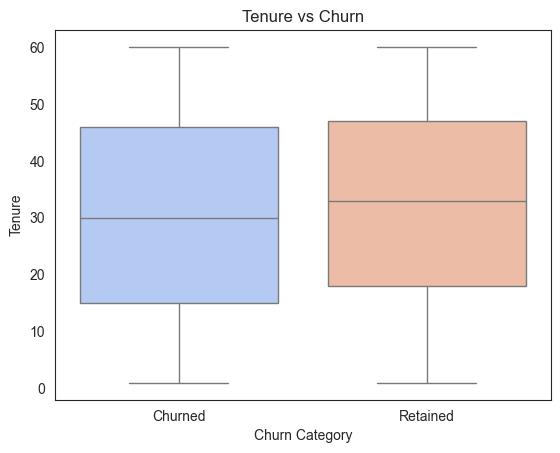

In [95]:
sns.boxplot(x='Churn Category', y='Tenure', data=df, palette='coolwarm')
plt.title('Tenure vs Churn')

In [96]:
(df['Tenure_Group'].value_counts(normalize=True)*100).round(1).astype(str) + '%'    

Tenure_Group
5-Years    21.3%
4-Years    21.2%
3-Years    20.9%
2-Years    18.5%
1-Year     18.1%
Name: proportion, dtype: object

Churn rate in each tenure group

In [97]:
(df.groupby('Tenure_Group',observed=False)['Churn'].mean()*100).round(1).astype(str) + '%'
# churn rate اعلي شويه في Durations القليله
#النسبه الاكبر من العملاء كانو بيقعدوا فترات طويله و نسبه كبيره منهم سابو الخدمه في الاخر 

Tenure_Group
1-Year     58.5%
2-Years    63.2%
3-Years    54.9%
4-Years    54.0%
5-Years    54.4%
Name: Churn, dtype: object

In [183]:
df.groupby(['Churn Category','Tenure_Group'])['Support Calls'].mean()

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\409583076.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Churn Category','Tenure_Group'])['Support Calls'].mean()


Churn Category  Tenure_Group
Churned         1-Year          5.146450
                2-Years         5.106900
                3-Years         5.128910
                4-Years         5.169330
                5-Years         5.171565
Retained        1-Year          1.601073
                2-Years         1.584422
                3-Years         1.587178
                4-Years         1.585599
                5-Years         1.577464
Name: Support Calls, dtype: float64

In [184]:
df.groupby(['Churn Category','Tenure_Group'])['Total Spend'].mean()

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\2198529605.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Churn Category','Tenure_Group'])['Total Spend'].mean()


Churn Category  Tenure_Group
Churned         1-Year          541.090609
                2-Years         543.140936
                3-Years         542.548527
                4-Years         540.914454
                5-Years         538.513629
Retained        1-Year          749.533966
                2-Years         751.985738
                3-Years         749.591207
                4-Years         750.125647
                5-Years         749.201933
Name: Total Spend, dtype: float64

In [185]:
df.groupby(['Churn Category','Tenure_Group'])['Payment Delay'].mean()

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\3045586988.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Churn Category','Tenure_Group'])['Payment Delay'].mean()


Churn Category  Tenure_Group
Churned         1-Year          15.245260
                2-Years         15.211584
                3-Years         15.192539
                4-Years         15.211144
                5-Years         15.225311
Retained        1-Year          10.019105
                2-Years         10.057763
                3-Years          9.987285
                4-Years         10.006708
                5-Years         10.018432
Name: Payment Delay, dtype: float64

In [186]:
df.groupby(['Churn Category','Tenure_Group'])['Usage Frequency'].mean()

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\1099668668.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Churn Category','Tenure_Group'])['Usage Frequency'].mean()


Churn Category  Tenure_Group
Churned         1-Year          15.498780
                2-Years         15.309760
                3-Years         15.516023
                4-Years         15.481854
                5-Years         15.506815
Retained        1-Year          15.492426
                2-Years         20.006516
                3-Years         15.791837
                4-Years         15.492167
                5-Years         15.520911
Name: Usage Frequency, dtype: float64

In [103]:
df[df['Tenure_Group']=='2-Years']['Churn'].mean()
# اكبر duration في Churn rate و اكتر duration ال features بتاعته بتبعد فكره ان يحصل churn اصلا

np.float64(0.6317657497781721)

In [104]:
df[df['Tenure_Group']=='2-Years']['Usage Frequency'].mean()

np.float64(17.039266655835636)

In [105]:
df[df['Tenure_Group']=='2-Years']['Support Calls'].mean()

np.float64(3.809802916880163)

In [106]:
df[df['Tenure_Group']=='2-Years']['Payment Delay'].mean()

np.float64(13.313770823699963)

In [191]:
df[df['Tenure_Group']=='2-Years']['Usage Frequency'].mean()

np.float64(17.039266655835636)

### Support Calls

In [107]:
(df['Support Calls'].value_counts(normalize=True)*100).round(1).astype(str)+'%'

Support Calls
0     15.9%
1     15.8%
2     15.1%
3     12.0%
4      8.8%
5      5.7%
10     5.4%
7      5.4%
9      5.4%
8      5.3%
6      5.3%
Name: proportion, dtype: object

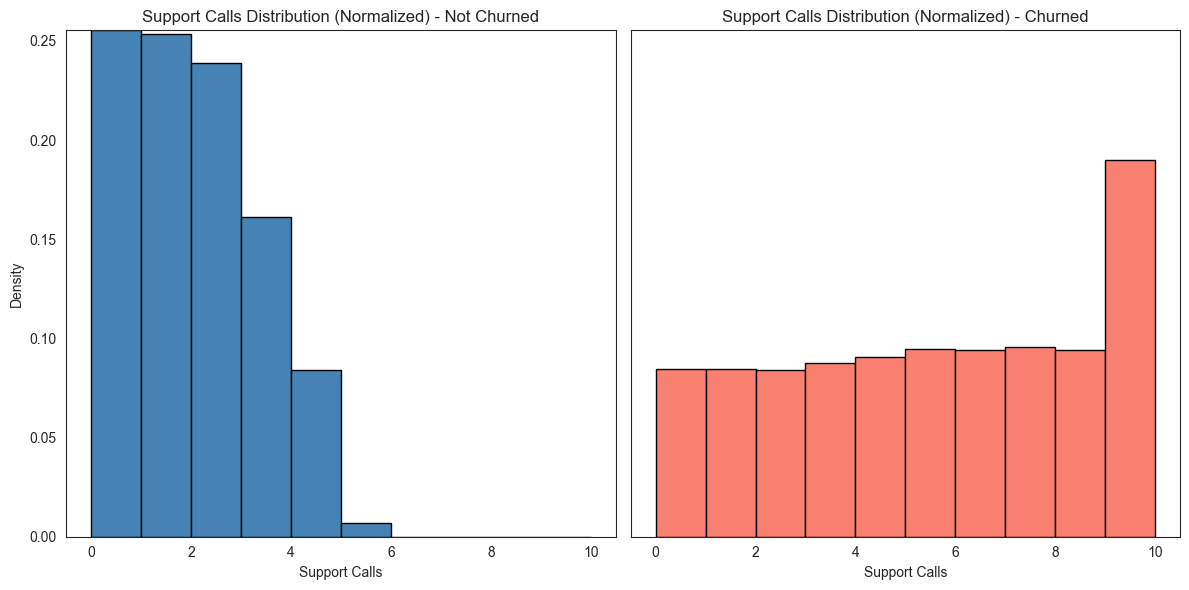

In [ ]:
support_min = df["Support Calls"].min()    # all people whose support calls were more than 6 have churned
support_max = df["Support Calls"].max()

dens_not, _ = np.histogram(
    df[df["Churn"] == 0]["Support Calls"],
    bins=10,
    range=(support_min, support_max),
    density=True
)

dens_churn, _ = np.histogram(
    df[df["Churn"] == 1]["Support Calls"],
    bins=20,
    range=(support_min, support_max),
    density=True
)

y_max = max(dens_not.max(), dens_churn.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

ax1.hist(
    df[df["Churn"] == 0]["Support Calls"],
    bins=10,
    range=(support_min, support_max),
    color='steelblue',
    edgecolor='black',
    density=True
)
ax1.set_title("Support Calls Distribution (Normalized) - Not Churned")
ax1.set_xlabel("Support Calls")
ax1.set_ylabel("Density")
ax1.set_ylim(0, y_max)

ax2.hist(
    df[df["Churn"] == 1]["Support Calls"],
    bins=10,
    range=(support_min, support_max),
    color='salmon',
    edgecolor='black',
    density=True
)
ax2.set_title("Support Calls Distribution (Normalized) - Churned")
ax2.set_xlabel("Support Calls")
ax2.set_ylim(0, y_max)

plt.tight_layout()
plt.show()

In [109]:
df.groupby('Churn Category')['Support Calls'].mean()

Churn Category
Churned     5.144861
Retained    1.586418
Name: Support Calls, dtype: float64

distribution of support calls over churned customers

In [110]:
(df[df['Churn']==1]['Support Calls'].value_counts(normalize=True)*100).round(1).astype(str)+'%'

Support Calls
10    9.6%
7     9.5%
9     9.5%
5     9.4%
8     9.4%
6     9.4%
4     9.1%
3     8.8%
0     8.5%
1     8.4%
2     8.4%
Name: proportion, dtype: object

percentage of support calls of churned from all

In [111]:
total_calls = df['Support Calls'].value_counts()
churn_calls = df[df['Churn'] == 1]['Support Calls'].value_counts()
result = (churn_calls / total_calls * 100).round(2).fillna(0)
result.astype(str) + '%'

Support Calls
0     30.28%
1     30.36%
2     31.55%
3     41.64%
4      58.5%
5     94.71%
6     100.0%
7     100.0%
8     100.0%
9     100.0%
10    100.0%
Name: count, dtype: object

### Payment Delay

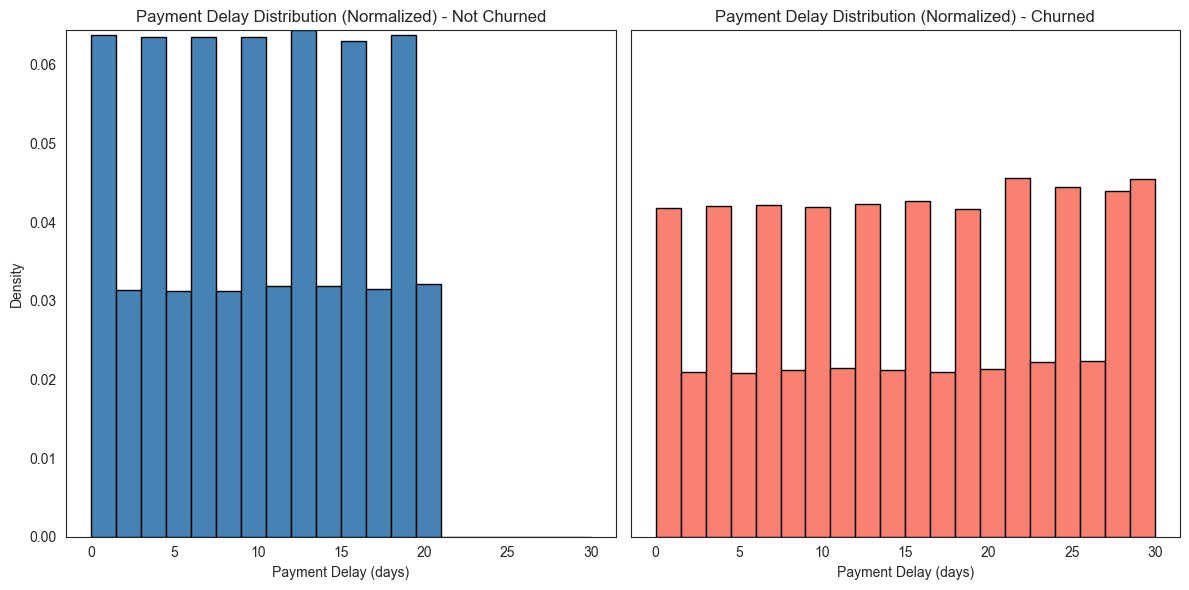

In [ ]:
delay_min = df["Payment Delay"].min()                  # all people whose payment delay exceeded 20 days churned --> dangerous indicator
delay_max = df["Payment Delay"].max()

dens_not, _ = np.histogram(
    df[df["Churn"] == 0]["Payment Delay"],
    bins=20,
    range=(delay_min, delay_max),
    density=True
)

dens_churn, _ = np.histogram(
    df[df["Churn"] == 1]["Payment Delay"],
    bins=20,
    range=(delay_min, delay_max),
    density=True
)

y_max = max(dens_not.max(), dens_churn.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

ax1.hist(
    df[df["Churn"] == 0]["Payment Delay"],
    bins=20,
    range=(delay_min, delay_max),
    color='steelblue',
    edgecolor='black',
    density=True
)
ax1.set_title("Payment Delay Distribution (Normalized) - Not Churned")
ax1.set_xlabel("Payment Delay (days)")
ax1.set_ylabel("Density")
ax1.set_ylim(0, y_max)

ax2.hist(
    df[df["Churn"] == 1]["Payment Delay"],
    bins=20,
    range=(delay_min, delay_max),
    color='salmon',
    edgecolor='black',
    density=True
)
ax2.set_title("Payment Delay Distribution (Normalized) - Churned")
ax2.set_xlabel("Payment Delay (days)")
ax2.set_ylim(0, y_max)

plt.tight_layout()
plt.show()

In [113]:
round(df.groupby('Churn Category')['Payment Delay'].mean(),2)

Churn Category
Churned     15.22
Retained    10.02
Name: Payment Delay, dtype: float64

In [188]:
df.groupby('Payment Delay Group')['Support Calls'].mean()  # maybe there is a problem in payment

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\1794811934.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Payment Delay Group')['Support Calls'].mean()  # maybe there is a problem in payment


Payment Delay Group
1–10 days     3.274168
10–20 days    3.278256
20+days       4.998501
Name: Support Calls, dtype: float64

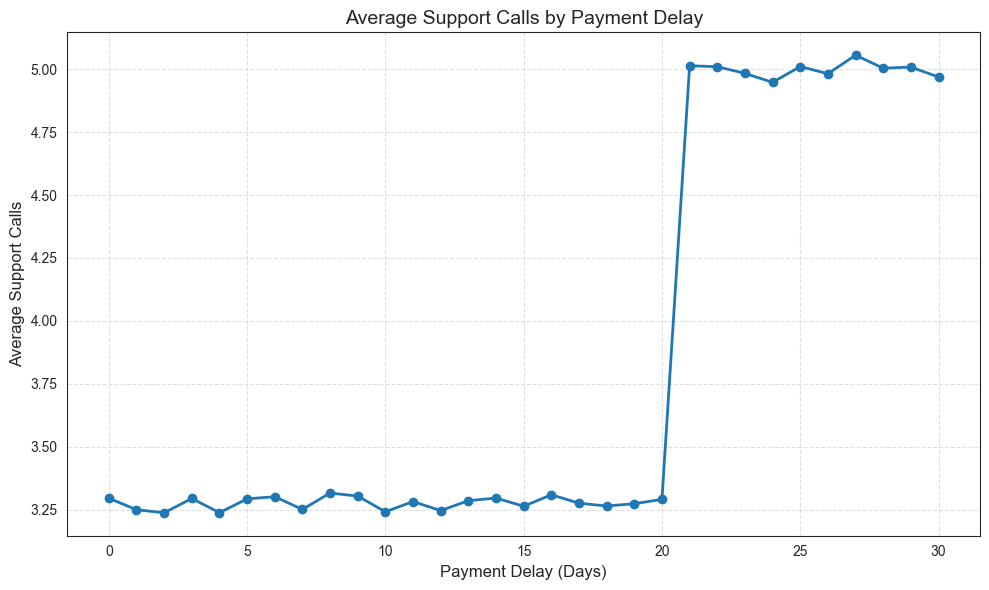

In [115]:
support_calls_by_delay = df.groupby('Payment Delay')['Support Calls'].mean()
plt.figure(figsize=(10,6))
plt.plot(support_calls_by_delay.index, support_calls_by_delay.values, marker='o', linestyle='-', linewidth=2)
plt.title('Average Support Calls by Payment Delay', fontsize=14)
plt.xlabel('Payment Delay (Days)', fontsize=12)
plt.ylabel('Average Support Calls', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

### Total Spend

In [116]:
round(df.groupby('Churn Category')['Total Spend'].mean(),2)

Churn Category
Churned     541.29
Retained    749.95
Name: Total Spend, dtype: float64

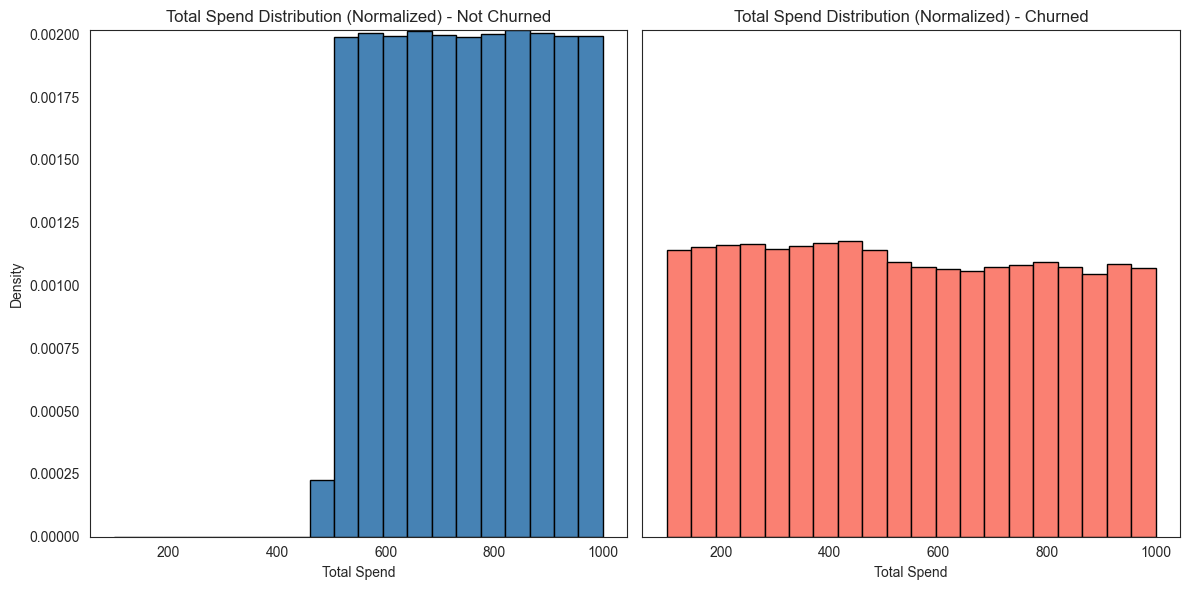

In [ ]:
spend_min = df["Total Spend"].min()
spend_max = df["Total Spend"].max()

dens_not, _ = np.histogram(
    df[df["Churn"] == 0]["Total Spend"],
    bins=20,
    range=(spend_min, spend_max),
    density=True
)

dens_churn, _ = np.histogram(
    df[df["Churn"] == 1]["Total Spend"],
    bins=20,
    range=(spend_min, spend_max),
    density=True
)

y_max = max(dens_not.max(), dens_churn.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

ax1.hist(
    df[df["Churn"] == 0]["Total Spend"],
    bins=20,
    range=(spend_min, spend_max),
    color='steelblue',
    edgecolor='black',
    density=True
)
ax1.set_title("Total Spend Distribution (Normalized) - Not Churned")
ax1.set_xlabel("Total Spend")
ax1.set_ylabel("Density")
ax1.set_ylim(0, y_max)

ax2.hist(
    df[df["Churn"] == 1]["Total Spend"],
    bins=20,
    range=(spend_min, spend_max),
    color='salmon',
    edgecolor='black',
    density=True
)
ax2.set_title("Total Spend Distribution (Normalized) - Churned")
ax2.set_xlabel("Total Spend")
ax2.set_ylim(0, y_max)

plt.tight_layout()
plt.show()

In [118]:
df["Total Spend"].corr(df["Tenure"])

np.float64(0.01900573929116822)

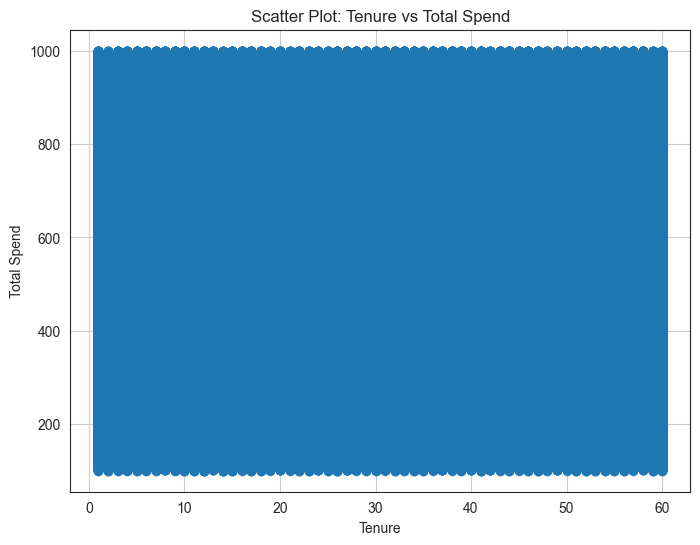

In [119]:
plt.figure(figsize=(8, 6))                                     # No correlation at all
plt.scatter(df["Tenure"], df["Total Spend"], alpha=0.6)

plt.title("Scatter Plot: Tenure vs Total Spend")
plt.xlabel("Tenure")
plt.ylabel("Total Spend")

plt.grid(True)
plt.show()

In [120]:
df.groupby('Subscription Type')['Total Spend'].mean()         # Subscription type has no impact

Subscription Type
Basic       628.673496
Premium     632.926463
Standard    633.132253
Name: Total Spend, dtype: float64

In [121]:
result = df.groupby([ "Tenure_Group","Subscription Type"],observed=False)["Total Spend"].mean().reset_index()   #No logic
result.sort_values(['Total Spend'],ascending=False)

,Tenure_Group,Subscription Type,Total Spend
9,4-Years,Basic,638.870517
7,3-Years,Premium,636.672496
11,4-Years,Standard,636.633622
1,1-Year,Premium,636.600987
6,3-Years,Basic,635.672518
10,4-Years,Premium,635.647411
8,3-Years,Standard,635.646007
2,1-Year,Standard,635.561492
12,5-Years,Basic,634.909711
13,5-Years,Premium,634.785226


#### Last Interaction

In [122]:
round(df.groupby('Churn Category')['Last Interaction'].mean(),2)

Churn Category
Churned     15.60
Retained    13.01
Name: Last Interaction, dtype: float64

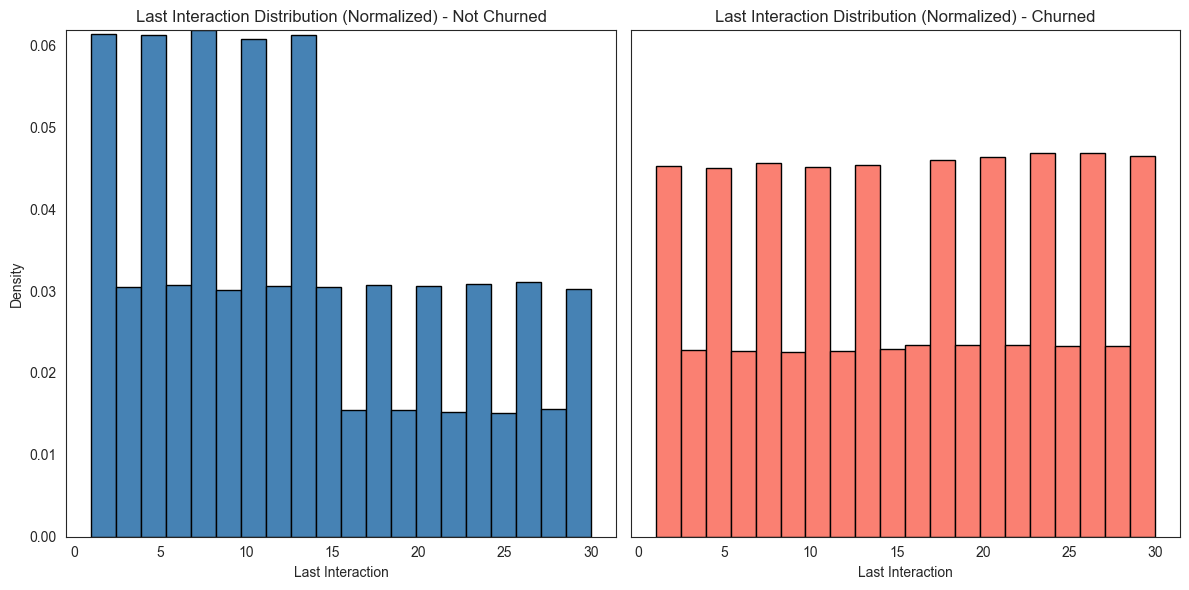

In [123]:
days_min = df["Last Interaction"].min()
days_max = df["Last Interaction"].max()

# حساب density لتوحيد y-limit
dens_not, _ = np.histogram(
    df[df["Churn"] == 0]["Last Interaction"],
    bins=20,
    range=(days_min, days_max),
    density=True
)

dens_churn, _ = np.histogram(
    df[df["Churn"] == 1]["Last Interaction"],
    bins=20,
    range=(days_min, days_max),
    density=True
)

y_max = max(dens_not.max(), dens_churn.max())

# ----------------------------
# الرسم باستخدام sharey=True
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Not churned
ax1.hist(
    df[df["Churn"] == 0]["Last Interaction"],
    bins=20,
    range=(days_min, days_max),
    color='steelblue',
    edgecolor='black',
    density=True
)
ax1.set_title("Last Interaction Distribution (Normalized) - Not Churned")
ax1.set_xlabel("Last Interaction")
ax1.set_ylabel("Density")
ax1.set_ylim(0, y_max)

# Churned
ax2.hist(
    df[df["Churn"] == 1]["Last Interaction"],
    bins=20,
    range=(days_min, days_max),
    color='salmon',
    edgecolor='black',
    density=True
)
ax2.set_title("Last Interaction Distribution (Normalized) - Churned")
ax2.set_xlabel("Last Interaction")
ax2.set_ylim(0, y_max)

plt.tight_layout()
plt.show()

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\3501086450.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn Category', y='Last Interaction', data=df, palette='coolwarm')


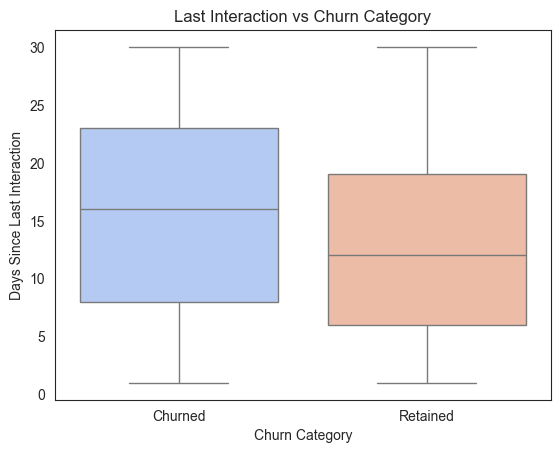

In [124]:
sns.boxplot(x='Churn Category', y='Last Interaction', data=df, palette='coolwarm')
plt.title('Last Interaction vs Churn Category')
plt.ylabel('Days Since Last Interaction')
plt.show()

percentage of each interaction level

In [125]:
(df['Interaction_Level'].value_counts(normalize=True)*100).round(1).astype(str)+'%'

Interaction_Level
At Risk [More]        47.0%
Very Active [Week]    26.6%
Active [2Weeks]       26.5%
Name: proportion, dtype: object

churn rate at each interaction level

In [126]:
(df.groupby('Interaction_Level',observed=False)['Churn'].mean()*100).round(1).astype(str) + '%'

Interaction_Level
Very Active [Week]    49.2%
Active [2Weeks]       49.3%
At Risk [More]        65.1%
Name: Churn, dtype: object

### Usage Frequency

In [127]:
(df['Usage Group'].value_counts(normalize=True)*100).round(1).astype(str)+'%'

Usage Group
20+ per month      34.3%
10–20 per month    34.3%
1–10 per month     31.4%
Name: proportion, dtype: object

In [128]:
df.groupby('Churn Category')['Usage Frequency'].mean()

Churn Category
Churned     15.461658
Retained    16.260552
Name: Usage Frequency, dtype: float64

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\1565053787.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn Category', y='Usage Frequency', data=df, palette='coolwarm')


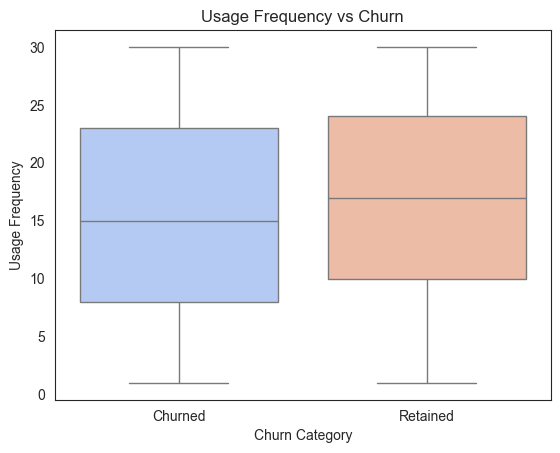

In [129]:
sns.boxplot(x='Churn Category', y='Usage Frequency', data=df, palette='coolwarm')
plt.title('Usage Frequency vs Churn')
plt.show()

In [130]:
(df.groupby('Tenure_Group')['Usage Group'].value_counts(normalize=True)*100).round(2).astype(str)+'%'

C:\Users\M.G\AppData\Local\Temp\ipykernel_1252\3684848690.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby('Tenure_Group')['Usage Group'].value_counts(normalize=True)*100).round(2).astype(str)+'%'


Tenure_Group  Usage Group    
1-Year        10–20 per month    33.48%
              1–10 per month     33.35%
              20+ per month      33.17%
2-Years       20+ per month      38.35%
              10–20 per month    37.95%
              1–10 per month      23.7%
3-Years       20+ per month      33.86%
              10–20 per month    33.65%
              1–10 per month     32.49%
4-Years       1–10 per month     33.47%
              10–20 per month    33.28%
              20+ per month      33.25%
5-Years       10–20 per month    33.49%
              20+ per month      33.38%
              1–10 per month     33.13%
Name: proportion, dtype: object